In [ ]:
# Basic libraries for data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For text cleaning
import re

# For removing stopwords and lemmatization
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter

# For splitting data
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# For building deep learning models
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print('All libraries loaded successfully!')

All libraries loaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set the path to your files in Google Drive
# Update the path below to match where your files are stored in your Drive
train_path = '/content/drive/MyDrive/sem 6 ai final assignment/rnn/text/train_racisit.csv'
test_path  = '/content/drive/MyDrive/sem 6 ai final assignment/rnn/text/test_racisit.csv'

# Load the datasets
train_df = pd.read_csv(train_path, engine='python', on_bad_lines='skip')
test_df  = pd.read_csv(test_path,  engine='python', on_bad_lines='skip')

# Check the shape and preview
print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('Train columns:', train_df.columns.tolist())
train_df.head()

Train shape: (31962, 3)
Test shape : (17197, 2)
Train columns: ['id', 'label', 'tweet']


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Label Distribution:
  Normal tweets        (0): 29720
  Racist/Sexist tweets (1): 2242
  Imbalance ratio (0:1)   : 13.26 x


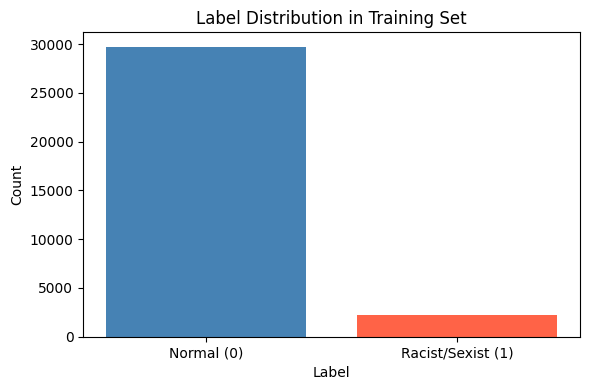

In [ ]:
# Count how many normal and racist/sexist tweets are in the training set
label_counts = Counter(train_df['label'])

print('Label Distribution:')
print('  Normal tweets        (0):', label_counts[0])
print('  Racist/Sexist tweets (1):', label_counts[1])
print('  Imbalance ratio (0:1)   :', round(label_counts[0] / label_counts[1], 2), 'x')

# Plot the distribution as a bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Normal (0)', 'Racist/Sexist (1)'],
        label_counts.values(),
        color=['steelblue', 'tomato'])
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Label Distribution in Training Set')
plt.tight_layout()
plt.show()

In [25]:
# Dictionary of common contractions to expand
contractions = {
    "don't": "do not", "can't": "cannot", "won't": "will not",
    "isn't": "is not", "aren't": "are not", "wasn't": "was not",
    "weren't": "were not", "haven't": "have not", "hasn't": "has not",
    "hadn't": "had not", "wouldn't": "would not", "couldn't": "could not",
    "shouldn't": "should not", "didn't": "did not", "doesn't": "does not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "it's": "it is",
    "we're": "we are", "we've": "we have", "they're": "they are",
    "they've": "they have", "that's": "that is", "there's": "there is"
}

# Updated preprocessing function with contraction handling
def preprocess_text(text):
    # Convert to lowercase
    text = str(text).lower()

    # Expand contractions before removing punctuation
    for contraction, expanded in contractions.items():
        text = text.replace(contraction, expanded)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove mentions (@user) and hashtag symbols (#)
    text = re.sub(r'\@\w+|\#', '', text)

    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove stopwords and lemmatize
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens     = text.split()
    tokens     = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return ' '.join(tokens)

# Apply preprocessing to both datasets
train_df['cleaned_text'] = train_df['tweet'].apply(preprocess_text)
test_df['cleaned_text']  = test_df['tweet'].apply(preprocess_text)

# Test with a contraction example
print('RAW     :', "I don't think this is right, it's wrong")
print('CLEANED :', preprocess_text("I don't think this is right, it's wrong"))
print('Preprocessing done!')

RAW     : I don't think this is right, it's wrong
CLEANED : think right wrong
Preprocessing done!


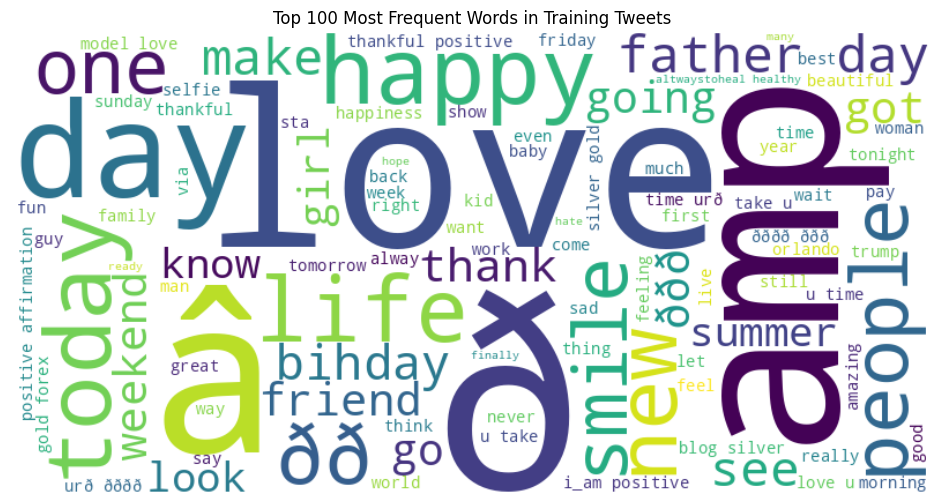

In [26]:
# Install wordcloud library
!pip install wordcloud

# Import wordcloud
from wordcloud import WordCloud

# Join all cleaned tweets into one big string
all_words = ' '.join(train_df['cleaned_text'])

# Generate the wordcloud with top 100 words
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(all_words)

# Plot the wordcloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Most Frequent Words in Training Tweets')
plt.show()

In [27]:
# Separate features and labels
X = train_df['cleaned_text'].tolist()
y = train_df['label'].tolist()

# Split into training and validation sets
# test_size=0.15 means 15% for validation, 85% for training
# stratify=y makes sure both sets have same ratio of 0s and 1s
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

print('Training samples  :', len(X_train))
print('Validation samples:', len(X_val))

Training samples  : 27167
Validation samples: 4795


In [28]:
# Create a tokenizer with a vocabulary size of 20000 words
# oov_token handles words that are not in the vocabulary
tokenizer = Tokenizer(num_words=20000, oov_token='<OOV>')

# Fit the tokenizer only on training data
tokenizer.fit_on_texts(X_train)

# Convert text to sequences of numbers
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(test_df['cleaned_text'].tolist())

print('Vocabulary size  :', len(tokenizer.word_index))
print('Example raw text :', X_train[0])
print('Example sequence :', X_train_seq[0])

Vocabulary size  : 36742
Example raw text : belgium rule muah ððª v â football soccer supoer belgium girl fun awesomâ
Example sequence : [2854, 1148, 12796, 2275, 357, 5, 479, 1888, 12797, 2854, 37, 39, 12798]


Max sequence length (99th percentile): 16
X_train_pad shape: (27167, 16)
X_val_pad shape  : (4795, 16)


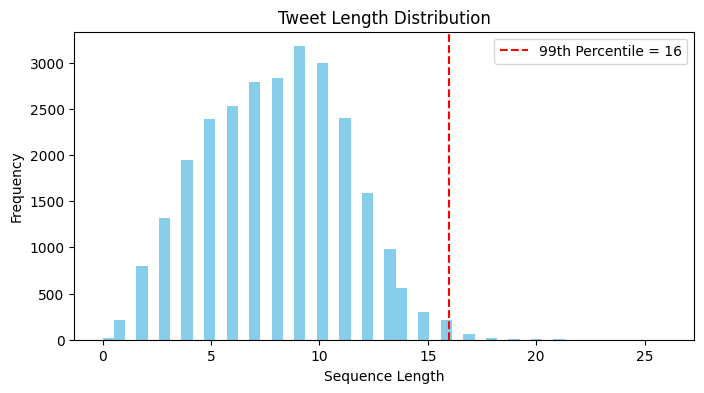

In [29]:
# Calculate the max length using 99th percentile of training sequence lengths
# This avoids making sequences too long because of a few outliers
seq_lengths = [len(seq) for seq in X_train_seq]
max_len     = int(np.percentile(seq_lengths, 99))
print('Max sequence length (99th percentile):', max_len)

# Pad all sequences to the same length
# padding='post' adds zeros at the end
# truncating='post' cuts from the end if sequence is too long
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

print('X_train_pad shape:', X_train_pad.shape)
print('X_val_pad shape  :', X_val_pad.shape)

# Plot the sequence length distribution
plt.figure(figsize=(8, 4))
plt.hist(seq_lengths, bins=50, color='skyblue')
plt.axvline(max_len, color='red', linestyle='dashed', label='99th Percentile = ' + str(max_len))
plt.title('Tweet Length Distribution')
plt.xlabel('Sequence Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [30]:
# Check class distribution in train and validation sets
train_counts = Counter(y_train)
val_counts   = Counter(y_val)

print('-- Class distribution --')
print('  Train -> Normal:', train_counts[0], ' Racist/Sexist:', train_counts[1])
print('  Val   -> Normal:', val_counts[0],   ' Racist/Sexist:', val_counts[1])
print('  Imbalance ratio:', round(train_counts[0] / max(train_counts[1], 1), 2), 'x')

# Check how many unknown words (OOV) are in the validation set
oov_idx      = tokenizer.word_index.get('<OOV>', 1)
total_tokens = X_val_pad[X_val_pad != 0].size
oov_tokens   = (X_val_pad == oov_idx).sum()

print('\n-- OOV rate on Validation Set --')
print('  OOV tokens :', oov_tokens)
print('  Total tokens:', total_tokens)
print('  OOV rate    :', round(oov_tokens / total_tokens * 100, 1), '%')

-- Class distribution --
  Train -> Normal: 25261  Racist/Sexist: 1906
  Val   -> Normal: 4459  Racist/Sexist: 336
  Imbalance ratio: 13.25 x

-- OOV rate on Validation Set --
  OOV tokens : 5521
  Total tokens: 38111
  OOV rate    : 14.5 %


In [31]:
# Define model parameters
vocab_size    = len(tokenizer.word_index) + 1  # Total number of unique words
embedding_dim = 128                             # Size of each word vector
hidden_units  = 64                              # Number of units in RNN/LSTM layer

# RNN Model
print('RNN MODEL')
print('-' * 50)
model_rnn = Sequential([
    Input(shape=(max_len,)),

    # Embedding layer converts word index to dense vector
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),

    # SimpleRNN layer processes the sequence
    SimpleRNN(units=hidden_units, return_sequences=False),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])
model_rnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_rnn.summary()

print()

# LSTM Model
print('LSTM MODEL')
print('-' * 50)
model_lstm = Sequential([
    Input(shape=(max_len,)),

    # Embedding layer converts word index to dense vector
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),

    # LSTM layer processes the sequence with memory gates
    LSTM(units=hidden_units, return_sequences=False),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_lstm.summary()

RNN MODEL
--------------------------------------------------


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 16, 128)        │     4,703,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,715,521 (17.99 MB)

 Trainable params: 4,715,521 (17.99 MB)

...

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 16, 128)        │     4,703,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,752,577 (18.13 MB)

 Trainable params: 4,752,577 (18.13 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# Checkpoint saves the best model based on validation loss
checkpoints_rnn = ModelCheckpoint(
    'rnn_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Early stopping stops training if validation loss does not improve
earlystopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Train the RNN model
history_rnn = model_rnn.fit(
    X_train_pad, np.array(y_train),
    validation_data=(X_val_pad, np.array(y_val)),
    epochs=10,
    batch_size=64,
    callbacks=[checkpoints_rnn, earlystopping]
)

Epoch 1/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9382 - loss: 0.2266
Epoch 1: val_loss improved from None to 0.13956, saving model to rnn_best_model.keras

Epoch 1: finished saving model to rnn_best_model.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 36s 68ms/step - accuracy: 0.9470 - loss: 0.1787 - val_accuracy: 0.9568 - val_loss: 0.1396
Epoch 2/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9801 - loss: 0.0626
Epoch 2: val_loss improved from 0.13956 to 0.13708, saving model to rnn_best_model.keras

Epoch 2: finished saving model to rnn_best_model.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 22s 52ms/step - accuracy: 0.9798 - loss: 0.0656 - val_accuracy: 0.9566 - val_loss: 0.1371
Epoch 3/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9940 - loss: 0.0210
Epoch 3: val_loss did not improve from 0.13708
425/425 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.9936 - loss: 0.0212 - val_accuracy: 0.9510 - val_loss: 0.1563
Epoch 4/10
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/

In [33]:
# This function evaluates a trained model and shows detailed results
def model_diagnosis(model, history, X_test_pad=X_val_pad, y_test=y_val):

    # Get prediction probabilities
    y_pred_proba = model.predict(X_test_pad)
    y_pred       = (y_pred_proba > 0.2).astype('int32').flatten()

    # Show prediction score statistics
    print('-- Prediction score stats --')
    print('  min :', round(float(y_pred_proba.min()), 4))
    print('  max :', round(float(y_pred_proba.max()), 4))
    print('  mean:', round(float(y_pred_proba.mean()), 4))
    print('  std :', round(float(y_pred_proba.std()), 4))

    # Show how predictions change at different thresholds
    print('\n-- Threshold sweep --')
    print('  Threshold    Pred Pos%    Pred Neg%')
    for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
        preds = (y_pred_proba > t).flatten()
        pp = preds.mean() * 100
        print('  ', round(t, 1), '        ', round(pp, 1), '        ', round(100 - pp, 1))

    # Overall accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print('\nAccuracy:', round(accuracy, 4))

    # Detailed classification report
    print('\n-- Classification Report --')
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Racist/Sexist']))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print('-- Confusion Matrix --')
    print('                 Pred Normal   Pred Racist')
    print('True Normal     ', cm[0, 0], '        ', cm[0, 1])
    print('True Racist     ', cm[1, 0], '        ', cm[1, 1])

    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ['loss', 'accuracy']):
        ax.plot(history.history[metric], label='train')
        ax.plot(history.history['val_' + metric], label='val')
        ax.set_title(metric)
        ax.legend()
    plt.tight_layout()
    plt.show()

    # Final diagnosis
    print('\n-- Diagnosis --')
    if y_pred_proba.max() - y_pred_proba.min() < 0.1:
        print('Scores are flat, model learned nothing')
    else:
        print('Model is working, try threshold tuning if needed')

RNN MODEL DIAGNOSIS
--------------------------------------------------
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
-- Prediction score stats --
  min : 0.0011
  max : 0.9926
  mean: 0.0855
  std : 0.2013

-- Threshold sweep --
  Threshold    Pred Pos%    Pred Neg%
   0.2          10.1          89.9
   0.3          7.9          92.1
   0.4          6.7          93.3
   0.5          5.8          94.2
   0.6          5.1          94.9

Accuracy: 0.9287

-- Classification Report --
               precision    recall  f1-score   support

       Normal       0.98      0.95      0.96      4459
Racist/Sexist       0.49      0.71      0.58       336

     accuracy                           0.93      4795
    macro avg       0.74      0.83      0.77      4795
 weighted avg       0.94      0.93      0.93      4795

-- Confusion Matrix --
                 Pred Normal   Pred Racist
True Normal      4214          245
True Racist      97          239


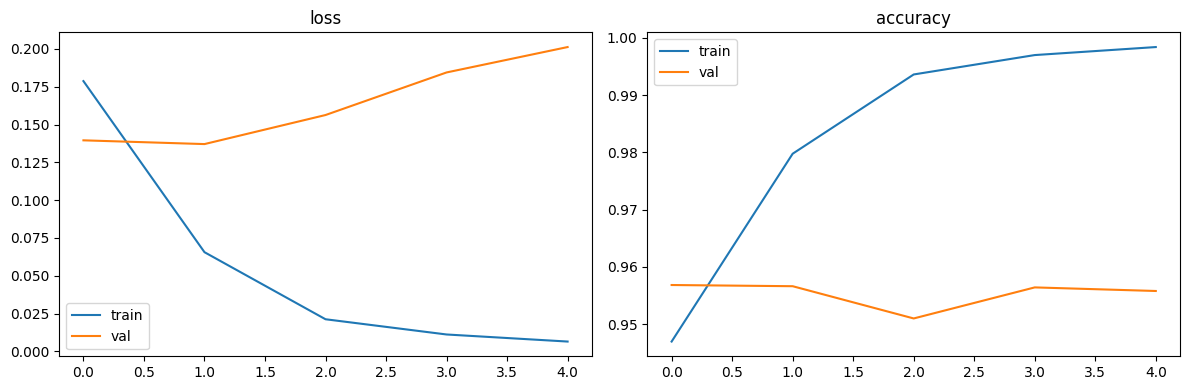


-- Diagnosis --
Model is working, try threshold tuning if needed


In [34]:
# Call the diagnosis function on the RNN model
print('RNN MODEL DIAGNOSIS')
print('-' * 50)
model_diagnosis(model_rnn, history=history_rnn)

In [35]:
# Checkpoint saves the best LSTM model based on validation loss
checkpoints_lstm = ModelCheckpoint(
    'lstm_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Early stopping stops training if validation loss does not improve
earlystopping2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Train the LSTM model
history_lstm = model_lstm.fit(
    X_train_pad, np.array(y_train),
    validation_data=(X_val_pad, np.array(y_val)),
    epochs=10,
    batch_size=64,
    callbacks=[checkpoints_lstm, earlystopping2]
)

Epoch 1/10
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9367 - loss: 0.2438
Epoch 1: val_loss improved from None to 0.12546, saving model to lstm_best_model.keras

Epoch 1: finished saving model to lstm_best_model.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 32s 69ms/step - accuracy: 0.9473 - loss: 0.1783 - val_accuracy: 0.9608 - val_loss: 0.1255
Epoch 2/10
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9769 - loss: 0.0725
Epoch 2: val_loss did not improve from 0.12546
425/425 ━━━━━━━━━━━━━━━━━━━━ 29s 68ms/step - accuracy: 0.9773 - loss: 0.0721 - val_accuracy: 0.9623 - val_loss: 0.1300
Epoch 3/10
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9894 - loss: 0.0363
Epoch 3: val_loss did not improve from 0.12546
425/425 ━━━━━━━━━━━━━━━━━━━━ 41s 68ms/step - accuracy: 0.9873 - loss: 0.0410 - val_accuracy: 0.9600 - val_loss: 0.1549
Epoch 4/10
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9930 - loss: 0.0234
Epoch 4: val_loss did not improve from 0.12546
425/425 ━━

LSTM MODEL DIAGNOSIS
--------------------------------------------------
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
-- Prediction score stats --
  min : 0.0023
  max : 0.9676
  mean: 0.0557
  std : 0.1794

-- Threshold sweep --
  Threshold    Pred Pos%    Pred Neg%
   0.2          6.0          94.0
   0.3          5.3          94.7
   0.4          4.8          95.2
   0.5          4.3          95.7
   0.6          3.8          96.2

Accuracy: 0.9597

-- Classification Report --
               precision    recall  f1-score   support

       Normal       0.97      0.98      0.98      4459
Racist/Sexist       0.75      0.64      0.69       336

     accuracy                           0.96      4795
    macro avg       0.86      0.81      0.83      4795
 weighted avg       0.96      0.96      0.96      4795

-- Confusion Matrix --
                 Pred Normal   Pred Racist
True Normal      4386          73
True Racist      120          216


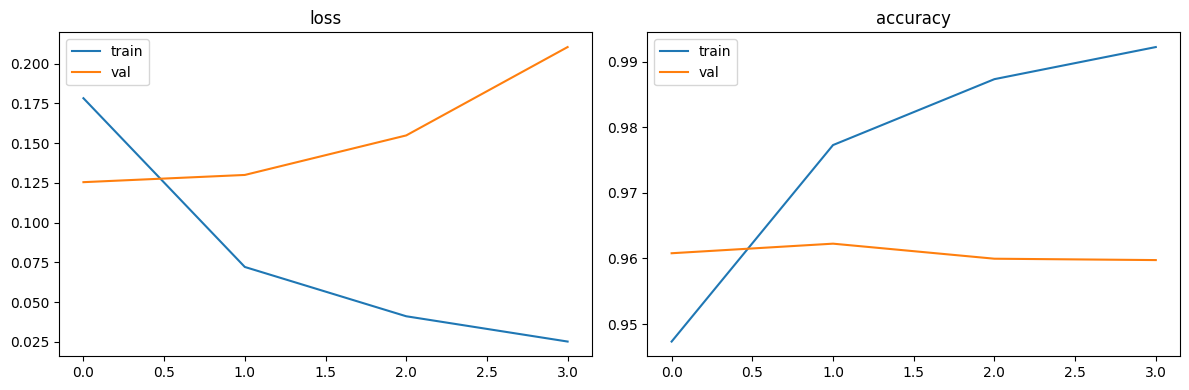


-- Diagnosis --
Model is working, try threshold tuning if needed


In [36]:
# Call the diagnosis function on the LSTM model
print('LSTM MODEL DIAGNOSIS')
print('-' * 50)
model_diagnosis(model_lstm, history=history_lstm)

In [37]:
# Use the LSTM model to predict on the unseen test set
test_preds_proba = model_lstm.predict(X_test_pad)

# Convert probabilities to labels using 0.2 threshold
test_preds = (test_preds_proba > 0.2).astype('int32').flatten()

# Add predictions to test dataframe
test_df['predicted_label'] = test_preds

# Show prediction distribution
print('Prediction distribution on test set:')
print('  Normal tweets        (0):', (test_preds == 0).sum())
print('  Racist/Sexist tweets (1):', (test_preds == 1).sum())

# Preview some predictions
test_df[['id', 'tweet', 'predicted_label']].head(10)

538/538 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
Prediction distribution on test set:
  Normal tweets        (0): 16062
  Racist/Sexist tweets (1): 1135


,id,tweet,predicted_label
0,31963,#studiolife #aislife #requires #passion #dedic...,0
1,31964,@user #white #supremacists want everyone to s...,1
2,31965,safe ways to heal your #acne!! #altwaystohe...,0
3,31966,is the hp and the cursed child book up for res...,0
4,31967,"3rd #bihday to my amazing, hilarious #nephew...",0
5,31968,choose to be :) #momtips,0
6,31969,something inside me dies ð¦ð¿â¨ eyes nes...,0
7,31970,#finished#tattoo#inked#ink#loveitâ¤ï¸ #â¤ï¸...,0
8,31971,@user @user @user i will never understand why...,0
9,31972,#delicious #food #lovelife #capetown mannaep...,0


In [38]:
# Function to predict sentiment on any custom tweet
def predict_tweet(text, model=model_lstm):
    # Clean the text using the same preprocessing function
    cleaned = preprocess_text(text)

    # Convert text to sequence of numbers
    seq = tokenizer.texts_to_sequences([cleaned])

    # Pad the sequence to match the model input size
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Get prediction probability
    prob = model.predict(padded, verbose=0)[0][0]

    # Return label and confidence
    if prob > 0.2:
        return 'Racist/Sexist', float(prob)
    else:
        return 'Normal', float(1 - prob)

# Test with some example tweets
test_tweets = [
    "I love everyone equally regardless of background.",
    "@user white people are destroying this country #hateful",
    "great game today! the team played amazingly well.",
    "women should stay at home and not work"
]

for tweet in test_tweets:
    label, confidence = predict_tweet(tweet)
    print('Tweet     :', tweet)
    print('Prediction:', label)
    print('Confidence:', round(confidence * 100, 2), '%')
    print()

Tweet     : I love everyone equally regardless of background.
Prediction: Normal
Confidence: 99.64 %

Tweet     : @user white people are destroying this country #hateful
Prediction: Racist/Sexist
Confidence: 94.44 %

Tweet     : great game today! the team played amazingly well.
Prediction: Normal
Confidence: 99.29 %

Tweet     : women should stay at home and not work
Prediction: Normal
Confidence: 88.77 %



In [40]:
# Install required libraries
!pip install numpy==1.23.5 -q
!pip install gensim -q

import gensim.downloader as api

# Load pretrained GloVe embeddings (50 dimensional)
# This may take a few minutes to download
print('Downloading pretrained GloVe embeddings...')
embedding_model = api.load('glove-twitter-50')
print('Download complete!')
print('Total words in embedding model:', len(embedding_model))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 33.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.7 MB/s eta 0:00:00
[==================================================] 100.0% 199.5/199.5MB downloaded
Download complete!
Total words in embedding model: 1193514


In [41]:
# Define embedding dimension to match glove-twitter-50
embedding_dim_w2v = 50

# Create an embedding matrix for all words in our vocabulary
embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

hit  = 0  # Words found in pretrained model
miss = 0  # Words not found in pretrained model

for word, index in tokenizer.word_index.items():
    if word in embedding_model:
        # Use the pretrained vector for this word
        embedding_matrix[index] = embedding_model[word]
        hit += 1
    else:
        # Randomly initialize words not found in pretrained model
        embedding_matrix[index] = np.random.normal(scale=0.6, size=(embedding_dim_w2v,))
        miss += 1

print('Words found in pretrained model :', hit)
print('Words not found                 :', miss)
print('Embedding matrix shape          :', embedding_matrix.shape)

Words found in pretrained model : 20320
Words not found                 : 16422
Embedding matrix shape          : (36743, 50)


In [42]:
# Build LSTM model with pretrained Word2Vec embeddings
model_lstm_w2v = Sequential([
    Input(shape=(max_len,)),

    # Embedding layer using pretrained weights
    # trainable=False means we keep the pretrained weights frozen
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        trainable=False
    ),

    # LSTM layer
    LSTM(units=64, return_sequences=False),

    # Output layer for binary classification
    Dense(1, activation='sigmoid')
])

model_lstm_w2v.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
print('LSTM with Word2Vec Model Summary')
print('-' * 50)
model_lstm_w2v.summary()

# Callbacks
checkpoints_w2v = ModelCheckpoint(
    'lstm_w2v_best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)
earlystopping_w2v = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Train the model
print('Training LSTM with Word2Vec...')
history_w2v = model_lstm_w2v.fit(
    X_train_pad, np.array(y_train),
    validation_data=(X_val_pad, np.array(y_val)),
    epochs=10,
    batch_size=64,
    callbacks=[checkpoints_w2v, earlystopping_w2v]
)

LSTM with Word2Vec Model Summary
--------------------------------------------------


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 16, 50)         │     1,837,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,866,655 (7.12 MB)

 Trainable params: 29,505 (115.25 KB)

 Non-trainable params: 1,837,150 (7.01 MB)

Training LSTM with Word2Vec...
Epoch 1/10
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9247 - loss: 0.2490
Epoch 1: val_loss improved from None to 0.15852, saving model to lstm_w2v_best_model.keras

Epoch 1: finished saving model to lstm_w2v_best_model.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.9352 - loss: 0.1908 - val_accuracy: 0.9458 - val_loss: 0.1585
Epoch 2/10
422/425 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9466 - loss: 0.1470
Epoch 2: val_loss improved from 0.15852 to 0.14513, saving model to lstm_w2v_best_model.keras

Epoch 2: finished saving model to lstm_w2v_best_model.keras
425/425 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9484 - loss: 0.1440 - val_accuracy: 0.9504 - val_loss: 0.1451
Epoch 3/10
423/425 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9516 - loss: 0.1319
Epoch 3: val_loss improved from 0.14513 to 0.13811, saving model to lstm_w2v_best_model.keras

Epoch 3: finished saving model to lstm_w2v_best_model.keras
425/425 ━

LSTM WITH WORD2VEC MODEL DIAGNOSIS
--------------------------------------------------
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step
-- Prediction score stats --
  min : 0.0002
  max : 0.9843
  mean: 0.0741
  std : 0.1916

-- Threshold sweep --
  Threshold    Pred Pos%    Pred Neg%
   0.2          9.7          90.3
   0.3          7.9          92.1
   0.4          6.5          93.5
   0.5          5.5          94.5
   0.6          4.5          95.5

Accuracy: 0.9343

-- Classification Report --
               precision    recall  f1-score   support

       Normal       0.98      0.95      0.96      4459
Racist/Sexist       0.52      0.73      0.61       336

     accuracy                           0.93      4795
    macro avg       0.75      0.84      0.79      4795
 weighted avg       0.95      0.93      0.94      4795

-- Confusion Matrix --
                 Pred Normal   Pred Racist
True Normal      4236          223
True Racist      92          244


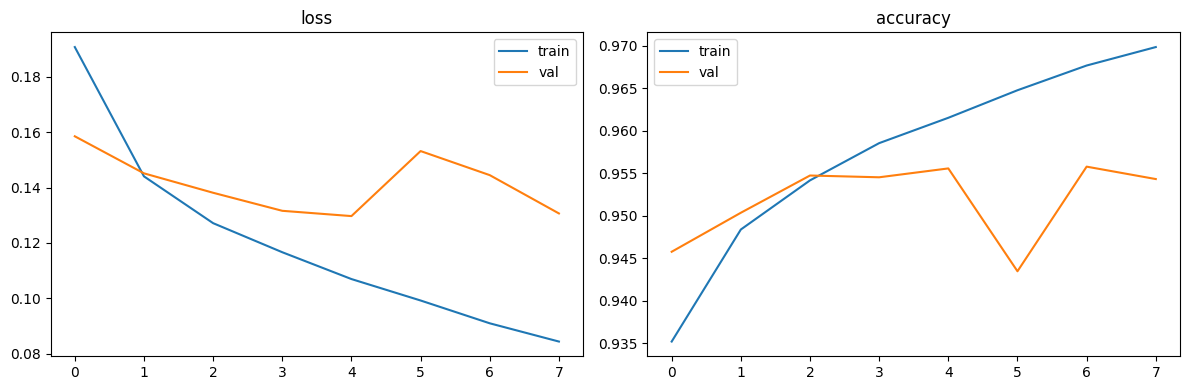


-- Diagnosis --
Model is working, try threshold tuning if needed


In [43]:
# Evaluate the Word2Vec LSTM model
print('LSTM WITH WORD2VEC MODEL DIAGNOSIS')
print('-' * 50)
model_diagnosis(model_lstm_w2v, history=history_w2v)

150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step


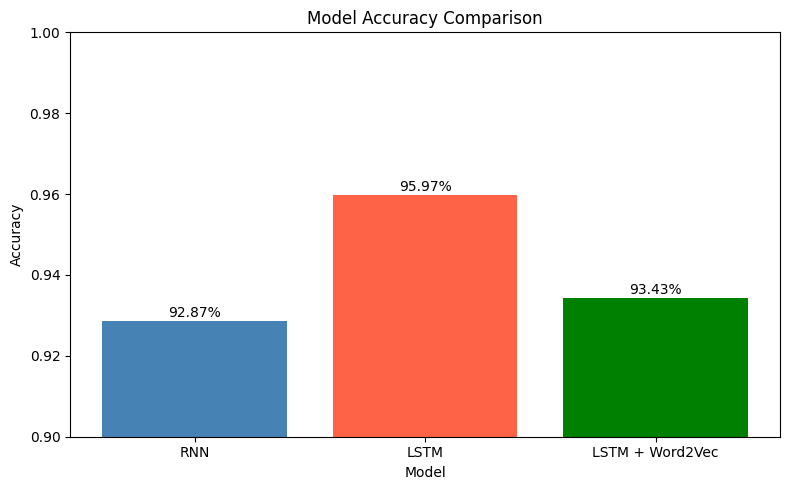

Model Comparison Summary
--------------------------------------------------
RNN : 92.87 %
LSTM : 95.97 %
LSTM + Word2Vec : 93.43 %


In [44]:
# Compare accuracy of all 3 models
models      = ['RNN', 'LSTM', 'LSTM + Word2Vec']
accuracies  = [
    accuracy_score(y_val, (model_rnn.predict(X_val_pad) > 0.2).astype('int32').flatten()),
    accuracy_score(y_val, (model_lstm.predict(X_val_pad) > 0.2).astype('int32').flatten()),
    accuracy_score(y_val, (model_lstm_w2v.predict(X_val_pad) > 0.2).astype('int32').flatten())
]

# Plot comparison bar chart
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['steelblue', 'tomato', 'green'])
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.90, 1.00)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.001, str(round(acc * 100, 2)) + '%', ha='center')
plt.tight_layout()
plt.show()

print('Model Comparison Summary')
print('-' * 50)
for model, acc in zip(models, accuracies):
    print(model, ':', round(acc * 100, 2), '%')

In [45]:
# Find misclassified examples from the validation set
y_pred_proba = model_lstm.predict(X_val_pad)
y_pred       = (y_pred_proba > 0.2).astype('int32').flatten()
y_true       = np.array(y_val)

# Get original tweets for validation set
val_tweets = train_df['tweet'].iloc[list(range(len(X_train), len(X_train) + len(X_val)))].reset_index(drop=True)

# Find wrong predictions
wrong_indices = np.where(y_pred != y_true)[0]

print('Total misclassified examples:', len(wrong_indices))
print()

# Show false negatives - racist tweets predicted as normal
print('-- False Negatives (Racist tweets predicted as Normal) --')
fn_count = 0
for i in wrong_indices:
    if y_true[i] == 1 and y_pred[i] == 0 and fn_count < 3:
        print('Tweet      :', val_tweets.iloc[i])
        print('True Label : Racist/Sexist')
        print('Predicted  : Normal')
        print('Confidence :', round(float(y_pred_proba[i]), 4))
        print('Reason     : Short or subtle tweet that lacks obvious racist keywords')
        print()
        fn_count += 1

# Show false positives - normal tweets predicted as racist
print('-- False Positives (Normal tweets predicted as Racist) --')
fp_count = 0
for i in wrong_indices:
    if y_true[i] == 0 and y_pred[i] == 1 and fp_count < 3:
        print('Tweet      :', val_tweets.iloc[i])
        print('True Label : Normal')
        print('Predicted  : Racist/Sexist')
        print('Confidence :', round(float(y_pred_proba[i]), 4))
        print('Reason     : Tweet contains words commonly associated with racist content')
        print()
        fp_count += 1

print('-- Possible Reasons for Errors --')
print('1. Class imbalance: only 7% of tweets are racist so model is biased towards normal')
print('2. Short tweets lack enough context for the model to decide correctly')
print('3. Subtle or sarcastic racist language is hard to detect')
print('4. Some words appear in both normal and racist tweets confusing the model')

print()
print('-- Suggested Improvements --')
print('1. Use oversampling techniques like SMOTE to handle class imbalance')
print('2. Use a larger pretrained model like BERT for better context understanding')
print('3. Increase training data for racist/sexist class')
print('4. Try different classification thresholds')

150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
Total misclassified examples: 193

-- False Negatives (Racist tweets predicted as Normal) --
Tweet      : alapoet: if  pisses you off like it pisses me off, here's something you oughta know... this guy's a racist â¦ 
True Label : Racist/Sexist
Predicted  : Normal
Confidence : 0.0053
Reason     : Short or subtle tweet that lacks obvious racist keywords

Tweet      : final planning before the #cftflaunch!  with @user &amp; cory.   #aintnopaylikeacftfpay #cardiff 
True Label : Racist/Sexist
Predicted  : Normal
Confidence : 0.0138
Reason     : Short or subtle tweet that lacks obvious racist keywords

Tweet      : brisk_and_fade-stay_here_forever__retro_rush-(ng024)-web-2002-ukhx_int . #next generation #web   hardcore #1gâ¦ 
True Label : Racist/Sexist
Predicted  : Normal
Confidence : 0.1298
Reason     : Short or subtle tweet that lacks obvious racist keywords

-- False Positives (Normal tweets predicted as Racist) --
Tweet      : 9941 #love,     a

/tmp/ipykernel_3706/451466683.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Confidence :', round(float(y_pred_proba[i]), 4))
/tmp/ipykernel_3706/451466683.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Confidence :', round(float(y_pred_proba[i]), 4))


In [39]:
# Install gradio library
!pip install gradio -q

import gradio as gr

# Function that gradio will call when user clicks predict
def classify(text):
    # Check if input is empty
    if not text.strip():
        return 'Please enter some text', 0.0

    # Get prediction
    label, confidence = predict_tweet(text, model_lstm)

    return label, round(confidence * 100, 2)

# Build the gradio interface
with gr.Blocks(title='Tweet Classifier', theme=gr.themes.Soft()) as demo:

    gr.Markdown('# Racist/Sexist Tweet Detector')
    gr.Markdown('### Powered by LSTM')

    with gr.Row():
        # Input column
        with gr.Column():
            text_input  = gr.Textbox(
                label='Enter a Tweet',
                placeholder='Type a tweet here...',
                lines=3
            )
            predict_btn = gr.Button('Classify', variant='primary')

        # Output column
        with gr.Column():
            label_out = gr.Label(label='Prediction')
            conf_out  = gr.Number(label='Confidence (%)')

    # Connect button to classify function
    predict_btn.click(
        fn=classify,
        inputs=text_input,
        outputs=[label_out, conf_out]
    )

# Launch the app with a public link
demo.launch(share=True)

/tmp/ipykernel_3706/3307517296.py:18: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title='Tweet Classifier', theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a82f3a2ba89c2d4a59.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
